In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

### Load cleaned data and selected features

In [2]:
df = pd.read_csv('../data/clean_encoded_insurance.csv')
features = pd.read_csv('../data/selected_features.csv').squeeze().tolist()
X = df[features]

### Scale

In [3]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)


In [4]:
# Find optimal K

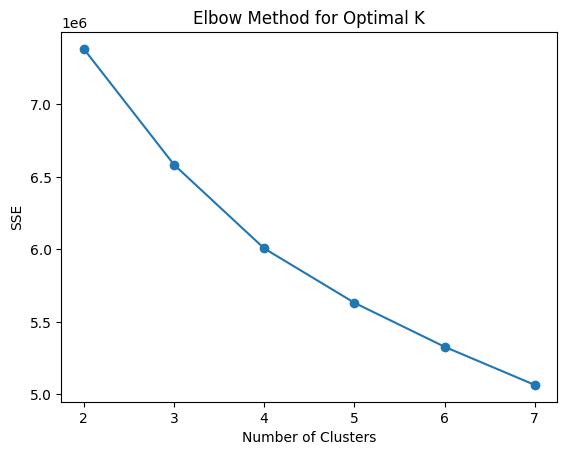

In [5]:
sse = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.plot(range(2, 8), sse, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

### Fit best K (say K=4)

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

### Evaluate cluster quality

In [7]:
print("Silhouette Score:", silhouette_score(X_scaled, df['Cluster']))
print("Davies–Bouldin:", davies_bouldin_score(X_scaled, df['Cluster']))

Silhouette Score: 0.12721884750902668
Davies–Bouldin: 2.0840073099901804


### Visualize PCA

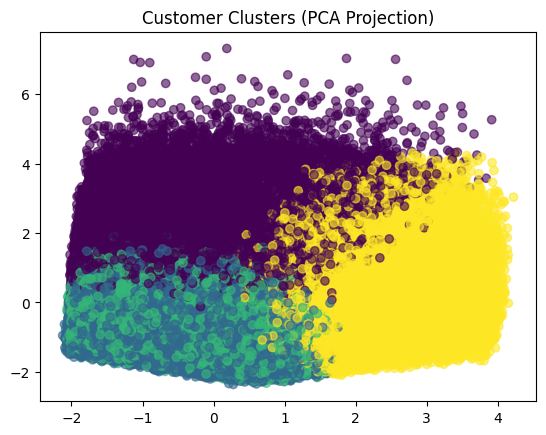

In [8]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
plt.scatter(pcs[:, 0], pcs[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.title("Customer Clusters (PCA Projection)")
plt.show()

### Save for next phase

In [9]:
df.to_csv('../data/clustered_insurance.csv', index=False)

In [10]:
cluster_summary = (
    df.groupby('Cluster')[['Premium Amount','Annual Income','Credit Score','Health Score','Previous Claims']]
    .mean()
    .round(2)
)
cluster_summary['Count'] = df['Cluster'].value_counts().sort_index()
print(cluster_summary)

         Premium Amount  Annual Income  Credit Score  Health Score  \
Cluster                                                              
0               1167.65       25381.05        616.11         25.49   
1               1083.77       21347.38        611.94         25.44   
2               1088.54       21531.29        610.79         25.32   
3               1106.26       92154.69        481.21         26.37   

         Previous Claims   Count  
Cluster                           
0                   2.37  198844  
1                   0.31  443418  
2                   0.31  366756  
3                   0.62  172270  


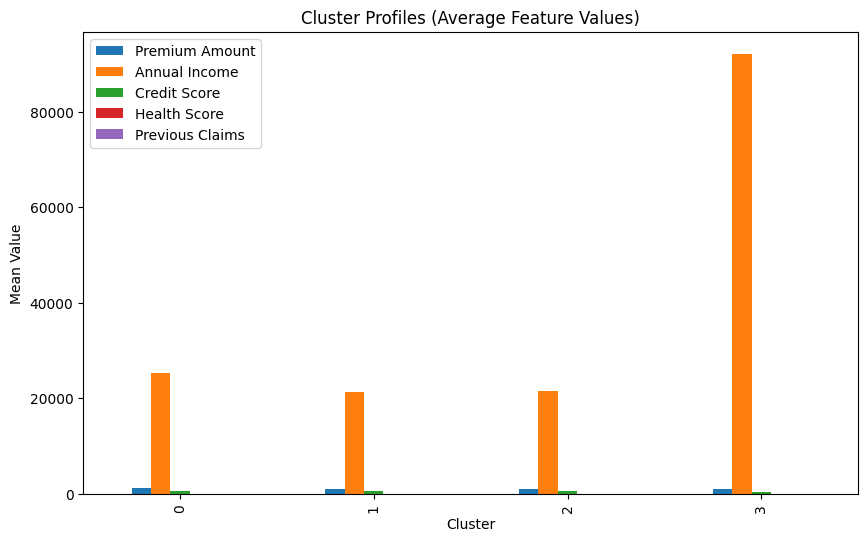

In [11]:
cluster_summary.drop(columns='Count').plot(kind='bar', figsize=(10,6))
plt.title("Cluster Profiles (Average Feature Values)")
plt.ylabel("Mean Value")
plt.show()